Creado por Luis Eduardo Reina Bermudez


## Actividad 01 Leer una sola hoja de un excel con varias hojas/pestañas

Librerias, por orden se cargan una sola vez al inicio

In [ ]:
import pandas as pd

In [ ]:


# Pequeños dataframes de ejemplo
df_matriculas = pd.DataFrame({
    "id_estudiante": [1, 2, 3, 4],
    "programa": ["Economía", "Ingeniería", "Psicología", "Economía"],
    "semestre": [1, 3, 2, 7]
})

df_notas = pd.DataFrame({
    "id_estudiante": [1, 1, 2, 3],
    "asignatura": ["Intro Eco", "Cálculo I", "Programación", "Estadística"],
    "nota": [4.3, 3.8, 4.5, 3.9]
})

df_costos = pd.DataFrame({
    "programa": ["Economía", "Ingeniería", "Psicología"],
    "matricula": [1800000, 2200000, 1900000]
})

nombre_archivo = "demostrativa_universidad.xlsx"# Aquí Guardamos todo en un solo archivo Excel con varias hojas

with pd.ExcelWriter(nombre_archivo) as writer:
    df_matriculas.to_excel(writer, sheet_name="Matriculas", index=False)
    df_notas.to_excel(writer, sheet_name="Notas", index=False)
    df_costos.to_excel(writer, sheet_name="Costos", index=False)

print(f"Archivo creado: {nombre_archivo}")


Archivo creado: demostrativa_universidad.xlsx


¿Siguiente paso? copiar la ruta... /content/demostrativa_universidad.xlsx

In [ ]:
#para leer una sola hoja del archivo, si conocemos el nombre exacto de la hoja (pilas con los espacios ocultos)
file = "/content/demostrativa_universidad.xlsx"
# reemplacen por el nombre de tu propio archivo, aunque sospecho que les debe quedar también en content

# Leer SOLO la hoja "Matriculas"
#df_matriculas = pd.read_excel(files, sheet_name="Matriculas")

df_notas = pd.read_excel(file, sheet_name="Notas")

# Recomendación : MongoDB y Neo4j... Lectura y representación de Bases de datos csv  como grafos..

df_notas


,id_estudiante,asignatura,nota
0,1,Intro Eco,4.3
1,1,Cálculo I,3.8
2,2,Programación,4.5
3,3,Estadística,3.9


In [ ]:
# Leer TODAS las hojas del archivo
dic_hojas = pd.read_excel(file, sheet_name=None) #aquí luego de la ruta del archivo indicamos en sheet_name None

type(dic_hojas), dic_hojas.keys()


(dict, dict_keys(['Matriculas', 'Notas', 'Costos']))

In [ ]:
df_matriculas = dic_hojas["Matriculas"]
df_notas = dic_hojas["Notas"]
df_costos = dic_hojas["Costos"]

df_notas.head()



,id_estudiante,asignatura,nota
0,1,Intro Eco,4.3
1,1,Cálculo I,3.8
2,2,Programación,4.5
3,3,Estadística,3.9


In [ ]:


# Leemos todas las hojas
dic_hojas = pd.read_excel(file, sheet_name=None)

df_por_hoja = {}  # aquí guardaremos los DataFrames “limpios”

for nombre_hoja, df in dic_hojas.items():
    print(f"Hoja encontrada: {nombre_hoja} | filas: {len(df)}")

    # Podrías hacer pequeñas limpiezas si quieres (ej: quitar espacios del nombre)
    nombre_limpio = nombre_hoja.strip().lower()  # 'Matriculas' -> 'matriculas'

    # Guardamos el df en el diccionario usando el nombre limpio
    df_por_hoja[nombre_limpio] = df

print("\nClaves finales en df_por_hoja:", df_por_hoja.keys())


Hoja encontrada: Matriculas | filas: 4
Hoja encontrada: Notas | filas: 4
Hoja encontrada: Costos | filas: 3

Claves finales en df_por_hoja: dict_keys(['matriculas', 'notas', 'costos'])


In [ ]:
df_por_hoja["costos"].head()

,programa,matricula
0,Economía,1800000
1,Ingeniería,2200000
2,Psicología,1900000


## Actividad 02 , consumiendo una API

In [ ]:
import requests   # esta libreria la usaremos ppara hacer la consulta HTTP
import json
import pandas as pd
from io import StringIO

In [ ]:
# Nivel 1: llamada simple a una API
#Esta en particular devuelve cadenas inventadas...
url = "https://jsonplaceholder.typicode.com/posts"  # Reemplazar por una api que encuentren como la de la upme...
respuesta = requests.get(url)
'''
#GET /posts devuelve 100 publicaciones simuladas
(una lista de objetos JSON con campos típicos como userId, id, title, body).

'''
print("Código de estado HTTP:", respuesta.status_code)

# Verificamos que todo salió bien (200 = OK)
if respuesta.status_code == 200:
    datos = respuesta.json()          # esto suele ser una lista de diccionarios
    df_posts = pd.DataFrame(datos)    # lo pasamos a DataFrame
    display(df_posts.head())
else:
    print("Hubo un problema al consultar la API.")


Código de estado HTTP: 200


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


In [ ]:

url_oecd = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.NAD,DSD_NAAG@DF_NAAG_I?dimensionAtObservation=AllDimensions&format=jsondata"

resp = requests.get(url_oecd)
print("Status code:", resp.status_code)

data = resp.json()
list(data.keys())  # para ver las claves principales


Status code: 200


['meta', 'data', 'errors']

In [ ]:


# - añadimos "/all" para seleccionar todos los valores
# - acorde a instrucciónes del sitio web usamos format=csvfilewithlabels para que sea más fácil de leer con pandas
url_oecd_csv = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.SDD.NAD,DSD_NAAG@DF_NAAG_I/all"
    "?dimensionAtObservation=AllDimensions"
    "&lastNObservations=5"
    "&format=csvfilewithlabels"
)

resp = requests.get(url_oecd_csv)
print("Status code:", resp.status_code)

# Cargar el CSV directamente en un DataFrame
df_oecd = pd.read_csv(StringIO(resp.text))

df_oecd.head()



Status code: 200


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,DECIMALS,Decimals,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,CURRENCY,Currency
0,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
1,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
2,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
3,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
4,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable


## ACTIVIDAD 03, Combinando data frames

In [ ]:


# DF 1: estudiantes del grupo A
df_a = pd.DataFrame({
    "id": [1, 2, 3],
    "nombre": ["Ana", "Bruno", "Carla"],
    "grupo": ["A", "A", "A"]
})

# DF 2: estudiantes del grupo B
df_b = pd.DataFrame({
    "id": [4, 5],
    "nombre": ["Diego", "Eva"],
    "grupo": ["B", "B"]
})

print("DF A:")
display(df_a)

print("DF B:")
display(df_b)

# "Append" moderno: concatenar filas
#df_ab = pd.concat([df_a, df_b], ignore_index=True)
df_ab = pd.concat([df_b, df_a], ignore_index=True)

print("DF combinado (A + B):")
df_ab


DF A:


,id,nombre,grupo
0,1,Ana,A
1,2,Bruno,A
2,3,Carla,A


DF B:


,id,nombre,grupo
0,4,Diego,B
1,5,Eva,B


DF combinado (A + B):


,id,nombre,grupo
0,4,Diego,B
1,5,Eva,B
2,1,Ana,A
3,2,Bruno,A
4,3,Carla,A


In [ ]:
# Vemos las columnas reales primero (solo por si acaso)
df_oecd.columns


Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'FREQ',
       'Frequency of observation', 'REF_AREA', 'Reference area', 'MEASURE',
       'Measure', 'UNIT_MEASURE', 'Unit of measure', 'CHAPTER', 'Chapter',
       'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value',
       'ADJUSTMENT', 'Adjustment', 'COUNTERPART_AREA', 'Counterpart area',
       'SECTOR', 'Institutional sector', 'COUNTERPART_SECTOR',
       'Counterpart institutional sector', 'CONSOLIDATION',
       'Consolidation status', 'ACCOUNTING_ENTRY', 'Accounting entry',
       'TRANSACTION', 'Transaction', 'INSTR_ASSET', 'Instruments and assets',
       'MATURITY', 'Original and residual maturity', 'PRODUCT', 'Product',
       'PENSION_FUNDTYPE', 'Pension fund type', 'CURRENCY_DENOM',
       'Currency of denomination', 'VALUATION', 'Valuation', 'PRICE_BASE',
       'Price base', 'TRANSFORMATION', 'Transformation', 'TABLE_IDENTIFIER',
       'Table identifier', 'REF_YEAR_PRICE', 'Price reference year

In [ ]:
#Nivel 2: concatenar subconjuntos de df_oecd

# Elige dos países que existan en REF_AREA (ajusta códigos según tu salida)
paises_ejemplo = df_oecd["REF_AREA"].unique()[:3]  ##(o podemos trabajar con los tres últimos [:3] )
pais1, pais2, pais3 = paises_ejemplo[0], paises_ejemplo[1], paises_ejemplo[2]
print("Usaremos como ejemplo los países:", pais1, "y", pais2, "y", pais3)




Usaremos como ejemplo los países: AUT y BRA y DEU


In [ ]:


df_pais1 = df_oecd[df_oecd["REF_AREA"] == pais1]
df_pais2 = df_oecd[df_oecd["REF_AREA"] == pais2]

print("\nSubconjunto país 1:")
display(df_pais1.head())

print("\nSubconjunto país 2:")
display(df_pais2.head())

print("\nSubconjunto país 3:")
display(df_pais2.head())

# "Append" / concat de ambos países
df_dos_paises = pd.concat([df_pais1, df_pais2], ignore_index=True)

print("\nDF con ambos países juntos:")
df_dos_paises.head()



Subconjunto país 1:


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,DECIMALS,Decimals,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,CURRENCY,Currency
0,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
1,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
2,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
3,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
4,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable



Subconjunto país 2:


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,DECIMALS,Decimals,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,CURRENCY,Currency
10,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
11,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
12,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
13,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
14,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable



Subconjunto país 3:


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,DECIMALS,Decimals,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,CURRENCY,Currency
10,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
11,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
12,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
13,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable
14,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,BRA,Brazil,B1GQ_POP,Gross domestic product per capita,...,F,Free (free for publication),2,Two,A,Normal value,0,Units,_Z,Not applicable



DF con ambos países juntos:


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency of observation,REF_AREA,Reference area,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,DECIMALS,Decimals,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,CURRENCY,Currency
0,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
1,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
2,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
3,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable
4,DATAFLOW,OECD.SDD.NAD:DSD_NAAG@DF_NAAG_I(1.0),NAAG Chapter 1: GDP,I,A,Annual,AUT,Austria,B1GQ,Gross domestic product,...,F,Free (free for publication),2,Two,A,Normal value,9,Billions,_Z,Not applicable


In [ ]:
# Mass nivel: merge entre dos DataFrames

# Info de estudiantes y el programa en que están
df_matriculas = pd.DataFrame({
    "id_estudiante": [1, 2, 3, 4],
    "nombre": ["Ana", "Bruno", "Carla", "Diego"],
    "programa": ["Economía", "Ingeniería", "Psicología", "Economía"]
})

# Info de costos por programa
df_costos = pd.DataFrame({
    "programa": ["Economía", "Ingeniería", "Psicología"],
    "matricula": [1_800_000, 2_200_000, 1_900_000]
})

#df_tercera = 5
#print(df_tercera)


print("DF matriculas:")
display(df_matriculas)

print("DF costos:")
display(df_costos)

# Unimos por la columna común 'programa'
df_combinada = pd.merge(df_matriculas, df_costos, on="programa", how="inner")

print("DF combinado (info estudiante + costo de programa):")
df_combinada




DF matriculas:


,id_estudiante,nombre,programa
0,1,Ana,Economía
1,2,Bruno,Ingeniería
2,3,Carla,Psicología
3,4,Diego,Economía


DF costos:


,programa,matricula
0,Economía,1800000
1,Ingeniería,2200000
2,Psicología,1900000


DF combinado (info estudiante + costo de programa):


,id_estudiante,nombre,programa,matricula
0,1,Ana,Economía,1800000
1,2,Bruno,Ingeniería,2200000
2,3,Carla,Psicología,1900000
3,4,Diego,Economía,1800000


In [ ]:
# Info de costos por programa
df_costos2 = pd.DataFrame({
    "programa": ["Economía", "Ingeniería", "Psicología", "Derecho"],
    "matricula": [1_800_000, 2_200_000, 1_900_000, 2_100_000]
})

In [ ]:
# Supongamos que agregamos un estudiante en un programa sin costo definido
df_matriculas2 = pd.DataFrame({
    "id_estudiante": [5],
    "nombre": ["Elena"],
    "programa": ["Derecho"]  # no está en df_costos
})

df_matriculas_ext = pd.concat([df_matriculas, df_matriculas2], ignore_index=True)

print("DF matriculas extendido:")
display(df_matriculas_ext)

# Hacemos un left merge: todos los estudiantes, costos si existen
df_left = pd.merge(df_matriculas_ext, df_costos2, on="programa", how="left")

print("Left merge (todos los estudiantes, costo si existe):")
df_left


DF matriculas extendido:


,id_estudiante,nombre,programa
0,1,Ana,Economía
1,2,Bruno,Ingeniería
2,3,Carla,Psicología
3,4,Diego,Economía
4,5,Elena,Derecho


Left merge (todos los estudiantes, costo si existe):


,id_estudiante,nombre,programa,matricula
0,1,Ana,Economía,1800000
1,2,Bruno,Ingeniería,2200000
2,3,Carla,Psicología,1900000
3,4,Diego,Economía,1800000
4,5,Elena,Derecho,2100000


## Actividad 04 Boxplots

In [ ]:
# Librerias, por orden se cargan una sola vez al inicio
import pandas as pd
import matplotlib.pyplot as plt

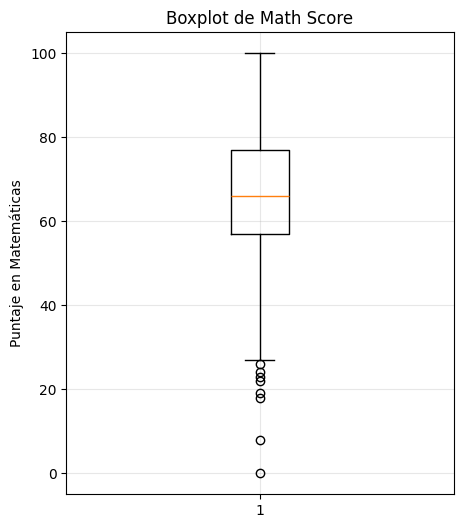

In [ ]:


plt.figure(figsize=(5,6))
plt.boxplot(df_exams["math score"], vert=True)
plt.title("Boxplot de Math Score")
plt.ylabel("Puntaje en Matemáticas")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
df_exams["math score"].describe()

,math score
count,1000.00000
mean,66.08900
std,15.16308
min,0.00000
25%,57.00000
50%,66.00000
75%,77.00000
max,100.00000


¿Porqué no funcionó?

In [ ]:
import kagglehub
import os

In [ ]:
import kagglehub as kh

# Download latest version
ruta = kh.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", ruta)
#aquí yo cambie path por ruta

csv_file = os.path.join(ruta, "StudentsPerformance.csv")  # ajusta el nombre si es distinto

df_exams = pd.read_csv(csv_file)


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


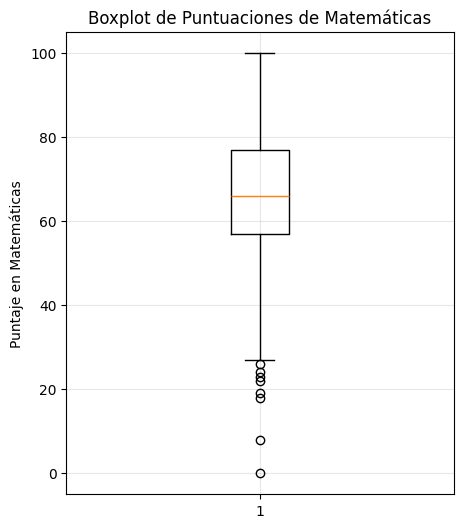

In [ ]:

plt.figure(figsize=(5,6))
plt.boxplot(df_exams["math score"], vert=True) #aquí esto porque ya revisamos las variables (columnas de la df_exams)
plt.title("Boxplot de Puntuaciones de Matemáticas")
plt.ylabel("Puntaje en Matemáticas")
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipython-input-2517859843.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=etiquetas)


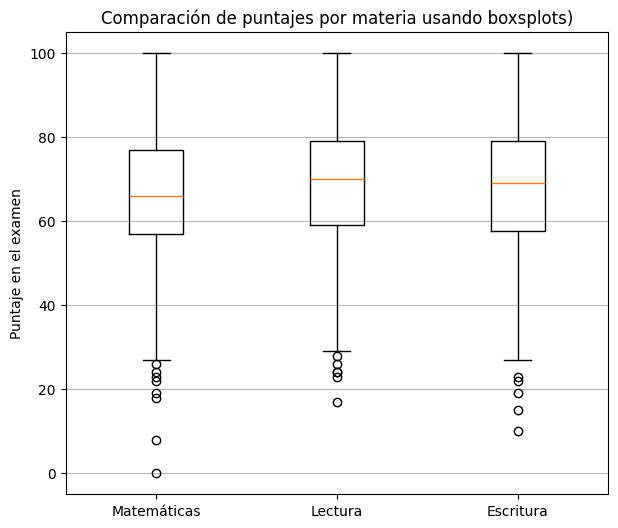

In [ ]:
# UN SEGUNDO ESCALON CON Boxplots,
## Boxplots de tres materias: math, reading, writing

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# Construimos una lista con las tres series numéricas
datos_box = [
    df_exams["math score"],
    df_exams["reading score"],
    df_exams["writing score"]
]

etiqueta = ["Matemáticas", "Lectura", "Escritura"] #cambie los nombres de las variables por equivalentes en Español...

plt.boxplot(datos_box, labels=etiquetas)

plt.title("Comparación de puntajes por materia usando boxsplots)")
plt.ylabel("Puntaje en el examen")
plt.grid(True, axis="y", alpha=0.9)

plt.show()


In [ ]:
# Actividad 05 graficos de barras por grupos


## Actividad 05 graficos de barras por grupos


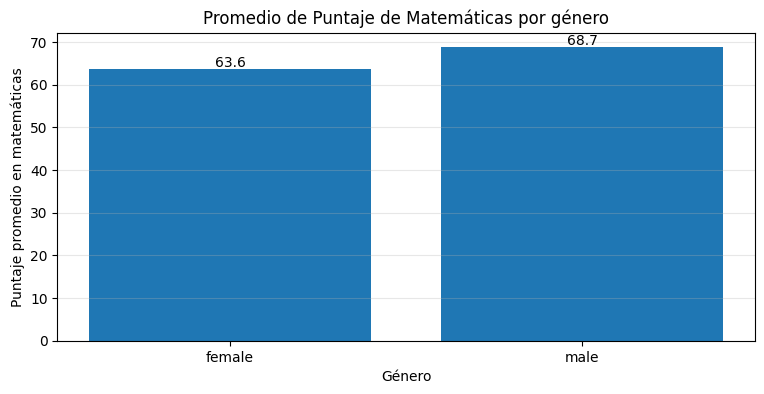

In [ ]:


#  Barras con df_exams: promedio de math por género
prom_math_genero = df_exams.groupby("gender")["math score"].mean() #aquí agrupo por cada una de las categeorias posibles en gender

plt.figure(figsize=(9,4))
plt.bar(prom_math_genero.index, prom_math_genero.values)

plt.title("Promedio de Puntaje de Matemáticas por género")
plt.xlabel("Género")
plt.ylabel("Puntaje promedio en matemáticas")
plt.grid(True, axis="y", alpha=0.3)

for i, v in enumerate(prom_math_genero.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center")

plt.show()


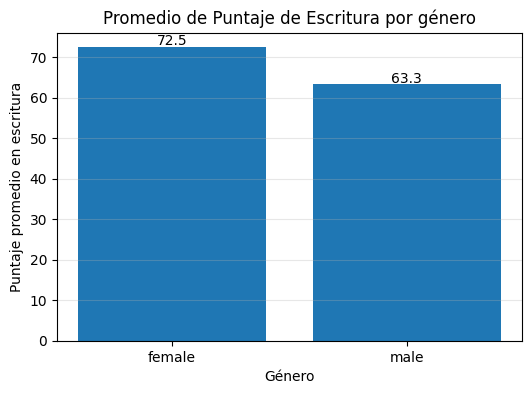

In [ ]:
#  Barras con df_exams: promedio de math por género
prom_math_genero = df_exams.groupby("gender")["writing score"].mean()

plt.figure(figsize=(6,4))
plt.bar(prom_math_genero.index, prom_math_genero.values)

plt.title("Promedio de Puntaje de Escritura por género")
plt.xlabel("Género")
plt.ylabel("Puntaje promedio en escritura")
plt.grid(True, axis="y", alpha=0.3)

for i, v in enumerate(prom_math_genero.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center")

plt.show()

In [ ]:
from textwrap import indent

#aquí les regalo una función para que usando las tres letras que identifican al país puedan llamar los datos de la API del World Bank
## Por ahora no se preocupen si no entienden la función lo importante aquí es que nos permitirá sacar algunos gráficos
### Desde luego también pretendo hacer un ejercicio de provocación para que se animen al nivel de programar, así sea apoyado con IA funciones.

def traer_wb_pais_indicador(pais_iso3, indicador, n=15):
#Qué debo indicarle a la función traer_wb_pais_imdicador? pues las tres letras ejemplo COL, luego el nombre del indicador, y finalmente la cantidad de los ultimos datos que quiero
    """
    Descarga desde la API del World Bank los últimos n años
    de un indicador para un país dado (código ISO3).
    Devuelve un DataFrame con columnas: countryiso3code, date, value.
    """
    url = f"https://api.worldbank.org/v2/country/{pais_iso3}/indicator/{indicador}"
    params = {
        "format": "json",
        "per_page": 200
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        print("Error HTTP:", r.status_code)
        return None

    data = r.json()
    registros = data[1]  # la segunda parte es la lista de observaciones
    df = pd.DataFrame(registros)

    # Extraemos nombre de país
    df["country_name"] = df["country"].apply(
        lambda x: x["value"] if isinstance(x, dict) else None
    )

    # Nos quedamos con columnas clave y convertimos año a int
    df = df[["countryiso3code", "country_name", "date", "value"]].copy()
    df["date"] = df["date"].astype(int)

    # Ordenamos por año y nos quedamos con los últimos n
    df = df.sort_values("date").tail(n)
    return df

# Probamos con Colombia y Estados Unidos
indicador_desempleo = "SL.UEM.TOTL.ZS" # Esto aquí me costo un poco mientras lo preparaba para ustedes, hay que de todas formas estudiar los diccionarios de datos del WB

df_col = traer_wb_pais_indicador("COL", indicador_desempleo, n=15)
df_usa = traer_wb_pais_indicador("USA", indicador_desempleo, n=15)
df_arg = traer_wb_pais_indicador("ARG", indicador_desempleo, n=15 )


display(df_col.head())
display(df_usa.head())
display(df_arg.head())


,countryiso3code,country_name,date,value
14,COL,Colombia,2010,11.153
13,COL,Colombia,2011,10.288
12,COL,Colombia,2012,9.959
11,COL,Colombia,2013,9.246
10,COL,Colombia,2014,8.799


,countryiso3code,country_name,date,value
14,USA,United States,2010,9.633
13,USA,United States,2011,8.949
12,USA,United States,2012,8.069
11,USA,United States,2013,7.375
10,USA,United States,2014,6.168


,countryiso3code,country_name,date,value
14,ARG,Argentina,2010,7.714
13,ARG,Argentina,2011,7.180
12,ARG,Argentina,2012,7.217
11,ARG,Argentina,2013,7.100
10,ARG,Argentina,2014,7.268


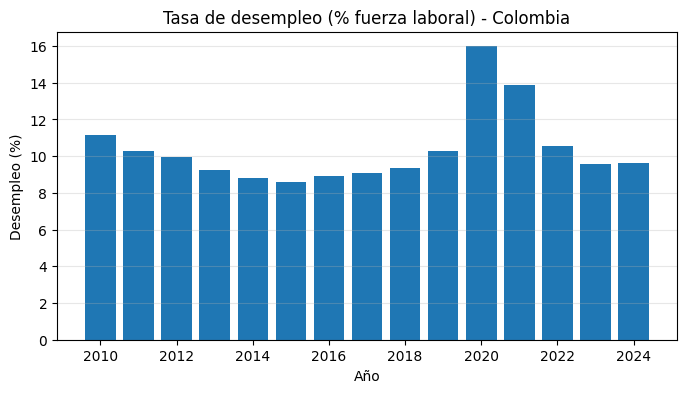

In [ ]:
# por fin podemos hacer el gráfico de Barras con datos macro: desempleo de Colombia

df_col_plot = df_col.dropna(subset=["value"])  # quitamos años sin dato

plt.figure(figsize=(8,4))
plt.bar(df_col_plot["date"], df_col_plot["value"])

plt.title("Tasa de desempleo (% fuerza laboral) - Colombia")
plt.xlabel("Año")
plt.ylabel("Desempleo (%)")
plt.grid(True, axis="y", alpha=0.3)

plt.show()


In [ ]:
# por fin podemos hacer el gráfico de Barras con datos macro: desempleo de Colombia
anio_comun = sorted(set(df_col["date"]) & set(df_usa["date"]))[-1]
anio_comun  ## la función de esto es Encontrar el último año en común entre los dos países, puesto que algunos países pueden haber dejado de reportar info ... en fin.


2024

,country_name,date,value
0,Colombia,2024,9.608
1,United States,2024,4.106


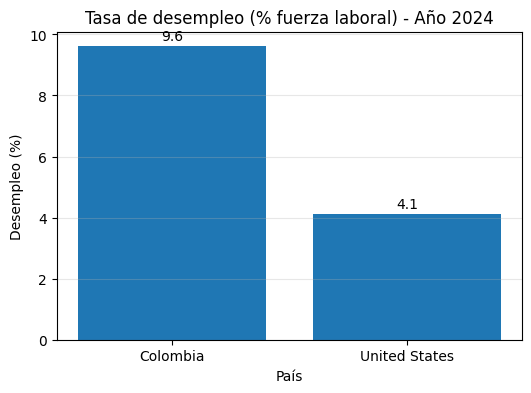

from matplotlib import pyplot as plt
_df_0['value'].plot(kind='hist', bins=20, title='value')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('country_name').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['value']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country_name')):
  _plot_series(series, series_name, i)
  fig.legend(title='country_name', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('value')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date'}, axis=1)
              .sort_values('date', ascending=True))
  xs = counted['date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country_name')):
  _plot_series(series, series_name, i)
  fig.legend(title='country_name', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_4['value'].plot(kind='line', figsize=(8, 4), title='value')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_5['country_name'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_5, x='value', y='country_name', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
#uno los df de colombia y usa
df_comparacion = pd.concat([
    df_col[df_col["date"] == anio_comun],
    df_usa[df_usa["date"] == anio_comun]
], ignore_index=True)

display(df_comparacion[["country_name", "date", "value"]])


#Luego si puedo hacer el gráfico.
plt.figure(figsize=(6,4))
plt.bar(df_comparacion["country_name"], df_comparacion["value"])

plt.title(f"Tasa de desempleo (% fuerza laboral) - Año {anio_comun}")
plt.xlabel("País")
plt.ylabel("Desempleo (%)")
plt.grid(True, axis="y", alpha=0.3)

for i, v in enumerate(df_comparacion["value"].values):
    plt.text(i, v + 0.2, f"{v:.1f}", ha="center")

plt.show()



# Actividad 06 ANOVAS y CORRELACIONES

In [ ]:
#librerias clave aquí...
!pip install statsmodels --quiet

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [ ]:
#Nivel 1: ANOVA de un factor con scipy (math  vs lunch)

# Creamos las dos muestras
grupo_standard = df_exams[df_exams["lunch"] == "standard"]["math score"]
grupo_free = df_exams[df_exams["lunch"] == "free/reduced"]["math score"]

# ANOVA de un factor (realmente aquí solo hay 2 grupos, pero el método admite k grupos)
F, p_valor = stats.f_oneway(grupo_standard, grupo_free)

print("ANOVA 1 factor: Math score según tipo de almuerzo")
print(f"Estadístico F: {F:.3f}")
print(f"p-valor: {p_valor:.5f}")


ANOVA 1 factor: Math score según tipo de almuerzo
Estadístico F: 140.119
p-valor: 0.00000


In [ ]:
#matriz de correlaciones

import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = df_exams[["math score", "lunch"]].copy()
df_anova.rename(columns={"math score": "math_score"}, inplace=True)

modelo1 = ols("math_score ~ C(lunch)", data=df_anova).fit()
tabla_anova1 = sm.stats.anova_lm(modelo1, typ=2)

tabla_anova1


,sum_sq,df,F,PR(>F)
C(lunch),28278.037838,1.0,140.118842,2.413196e-30
Residual,201411.041162,998.0,NaN,NaN


In [ ]:
corr_mat = df_exams[["math score", "reading score", "writing score"]].corr()
corr_mat

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


## Actividad 7  Heatmap

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Matriz de correlación:


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


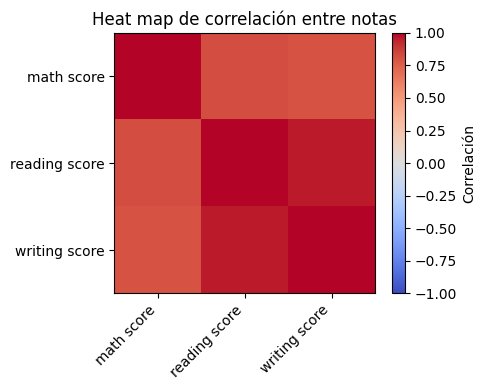

In [ ]:
## Heat map de correlaciones =====

# Seleccionamos solo las columnas numéricas que nos interesan
cols_notas = ["math score", "reading score", "writing score"]
corr = df_exams[cols_notas].corr()

print("Matriz de correlación:")
display(corr)

plt.figure(figsize=(5, 4))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")

# Etiquetas de filas y columnas
plt.xticks(ticks=np.arange(len(cols_notas)), labels=cols_notas, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(cols_notas)), labels=cols_notas)

plt.title("Heat map de correlación entre notas")
plt.tight_layout()
plt.show()


Promedio de math score por género y tipo de almuerzo:


lunch,free/reduced,standard
gender,,
female,55.814815,68.124620
male,62.457831,72.022152


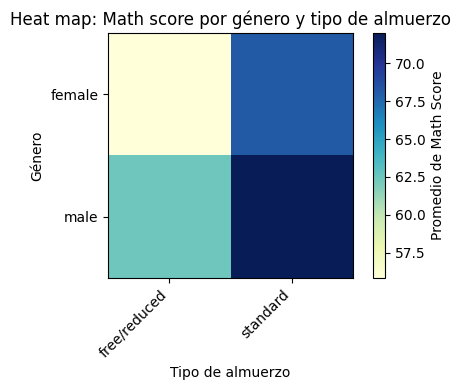

In [ ]:
# Nivel 2: Heat map de promedios por grupo (ya no es de correlación...)

tabla_prom = df_exams.pivot_table(
    index="gender",
    columns="lunch",
    values="math score",
    aggfunc="mean"
)

print("Promedio de math score por género y tipo de almuerzo:")
display(tabla_prom)

plt.figure(figsize=(5, 4))

plt.imshow(tabla_prom, cmap="YlGnBu")
plt.colorbar(label="Promedio de Math Score")

plt.xticks(
    ticks=np.arange(len(tabla_prom.columns)),
    labels=tabla_prom.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(tabla_prom.index)),
    labels=tabla_prom.index
)

plt.title("Heat map: Math score por género y tipo de almuerzo")
plt.xlabel("Tipo de almuerzo")
plt.ylabel("Género")
plt.tight_layout()
plt.show()


## Actividad 08 Regresión lineal

In [ ]:
#librerias necesarias, además de las normales de numpy y pandas...

import statsmodels.api as sm
from statsmodels.formula.api import ols


In [ ]:
#  Preparo una data amigable...
# Creamos una copia con nombres sin espacios
df_reg = df_exams[[
    "math score",
    "reading score",
    "writing score",
    "gender",
    "lunch"
]].copy()

df_reg.rename(columns={
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
}, inplace=True)

df_reg.head()


,math_score,reading_score,writing_score,gender,lunch
0,72,72,74,female,standard
1,69,90,88,female,standard
2,90,95,93,female,standard
3,47,57,44,male,free/reduced
4,76,78,75,male,standard


In [ ]:
#  Nivel 1: regresión lineal simple math_score en función de reading_score



modelo_simple = ols("math_score ~ reading_score", data=df_reg).fit()

# Resumen del modelo (con coeficientes, R², tests t, etc.)
print(modelo_simple.summary())


#¿Cuál diferencia con Stata??? (obvio Python no tiene revista cientifica propia, es la principal diferencia)

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     2012.
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          1.79e-241
Time:                        01:40:47   Log-Likelihood:                -3585.3
No. Observations:                1000   AIC:                             7175.
Df Residuals:                     998   BIC:                             7184.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.3576      1.338      5.498

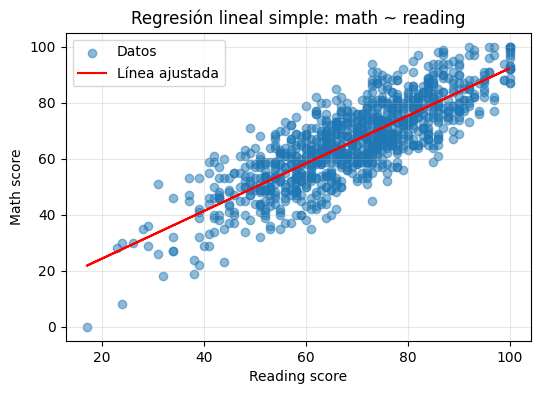

In [ ]:
#ñapa de nivel 1 de regresión lineal...

plt.figure(figsize=(6,4))
plt.scatter(df_reg["reading_score"], df_reg["math_score"], alpha=0.5, label="Datos")
plt.plot(df_reg["reading_score"], modelo_simple.fittedvalues,
         color="red", label="Línea ajustada")
plt.xlabel("Reading score")
plt.ylabel("Math score")
plt.title("Regresión lineal simple: math ~ reading")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
#Nivel 2 con regresión lineal multiple, usando también variable categórica

formula_mult = "math_score ~ reading_score + writing_score + C(gender)"

modelo_multiple = ols(formula_mult, data=df_reg).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:             math_score   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     1751.
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        01:42:44   Log-Likelihood:                -3219.1
No. Observations:                1000   AIC:                             6446.
Df Residuals:                     996   BIC:                             6466.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -6.1892      1.02

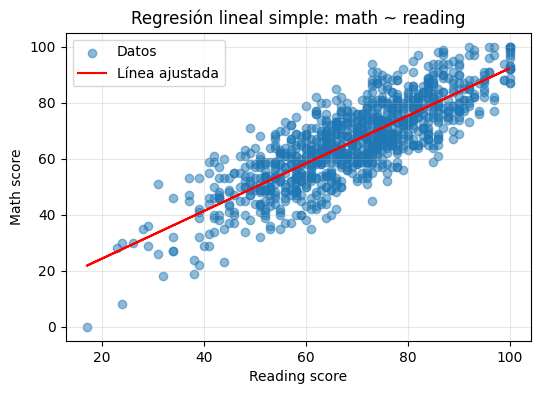

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_reg["reading_score"], df_reg["math_score"], alpha=0.5, label="Datos")
plt.plot(df_reg["reading_score"], modelo_simple.fittedvalues,
         color="red", label="Línea ajustada")
plt.xlabel("Reading score")
plt.ylabel("Math score")
plt.title("Regresión lineal simple: math ~ reading")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Actividad 09 Regresión Logística...

In [ ]:
from statsmodels.formula.api import logit

# Preparamos un df específico para la logística
df_logit = df_exams[[
    "math score",
    "reading score",
    "writing score",
    "gender",
    "lunch"
]].copy()

df_logit.rename(columns={
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
}, inplace=True)

# Definimos "alto desempeño" como math_score >= 70 (puedes cambiar el umbral)
umbral = 70
df_logit["alto_math"] = (df_logit["math_score"] >= umbral).astype(int)

df_logit.head()

,math_score,reading_score,writing_score,gender,lunch,alto_math
0,72,72,74,female,standard,1
1,69,90,88,female,standard,0
2,90,95,93,female,standard,1
3,47,57,44,male,free/reduced,0
4,76,78,75,male,standard,1


In [ ]:
# arrancando o level 1: regresión logística sencilla

modelo_logit_simple = logit("alto_math ~ reading_score", data=df_logit).fit()

print(modelo_logit_simple.summary())


Optimization terminated successfully.
         Current function value: 0.413266
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              alto_math   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Dec 2025   Pseudo R-squ.:                  0.3891
Time:                        22:33:06   Log-Likelihood:                -413.27
converged:                       True   LL-Null:                       -676.49
Covariance Type:            nonrobust   LLR p-value:                1.669e-116
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -11.8032      0.742    -15.897      0.000     -13.258     -10.348
reading_score     0.

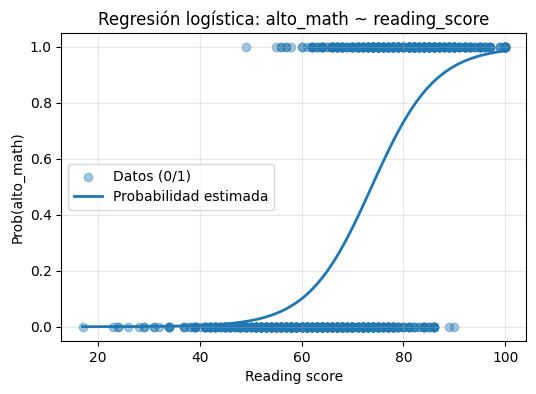

In [ ]:
# Creamos una malla de valores de lectura
x_vals = np.linspace(df_logit["reading_score"].min(), df_logit["reading_score"].max(), 100)
df_pred = pd.DataFrame({"reading_score": x_vals})

# Obtenemos probabilidades predichas
df_pred["prob_alto_math"] = modelo_logit_simple.predict(df_pred)

plt.figure(figsize=(6,4))
plt.scatter(df_logit["reading_score"], df_logit["alto_math"], alpha=0.4, label="Datos (0/1)")
plt.plot(df_pred["reading_score"], df_pred["prob_alto_math"], linewidth=2, label="Probabilidad estimada")
plt.xlabel("Reading score")
plt.ylabel("Prob(alto_math)")
plt.title("Regresión logística: alto_math ~ reading_score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Nivel 2: regresión logística múltiple

formula_logit_mult = "alto_math ~ reading_score + writing_score + C(gender) + C(lunch)"

modelo_logit_mult = logit(formula_logit_mult, data=df_logit).fit()

print(modelo_logit_mult.summary())


Optimization terminated successfully.
         Current function value: 0.284843
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              alto_math   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      995
Method:                           MLE   Df Model:                            4
Date:                Thu, 04 Dec 2025   Pseudo R-squ.:                  0.5789
Time:                        22:33:42   Log-Likelihood:                -284.84
converged:                       True   LL-Null:                       -676.49
Covariance Type:            nonrobust   LLR p-value:                3.184e-168
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -21.9475      1.451    -15.126      0.000     -24.791     -19.104

In [ ]:
coef = modelo_logit_mult.params
pvals = modelo_logit_mult.pvalues

resumen_logit = pd.DataFrame({
    "coeficiente": coef,
    "p_valor": pvals,
    "odds_ratio": np.exp(coef)
})

resumen_logit


,coeficiente,p_valor,odds_ratio
Intercept,-21.947501,1.099510e-51,2.939826e-10
C(gender)[T.male],3.804907,1.242578e-32,4.492109e+01
C(lunch)[T.standard],1.026197,1.389961e-05,2.790433e+00
reading_score,0.106639,3.744000e-05,1.112532e+00
writing_score,0.160463,5.078204e-09,1.174054e+00
